In [192]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Предобработка

In [193]:
df = pd.read_csv('data/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [194]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [195]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [196]:
y = df['species'].apply(lambda s: {
    'setosa': 1, 
    'versicolor': 2, 
    'virginica': 3
}[s])
X = df.drop('species', axis=1)

**Скейлинг**

In [197]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [198]:
SEED = 42

# k-means

In [199]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Метод локтя

[]

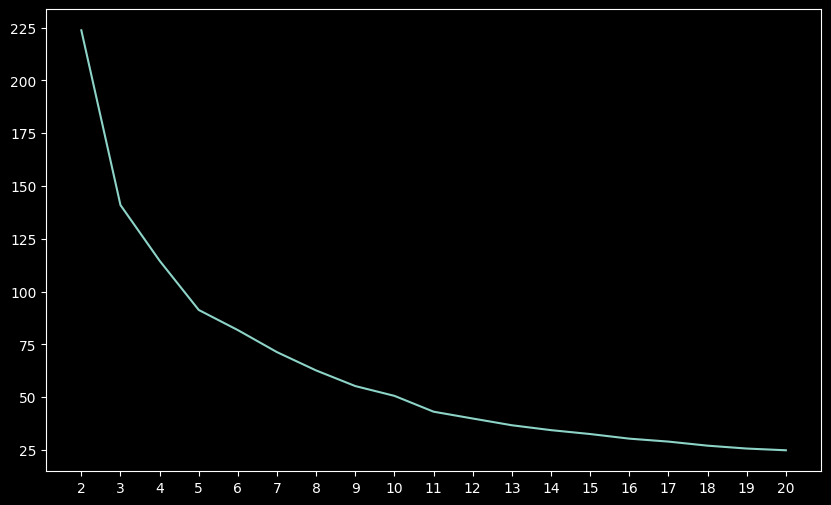

In [200]:
k_vals = list(range(2, 21))
scores = [] 

for k in k_vals:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    scores.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_vals, scores)
plt.xticks(k_vals)
plt.plot()

In [201]:
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print(f'kmeans silhouette score: {kmeans_score}')

kmeans silhouette score: 0.4589717867018717


# Агломеративаня  класстеризация

In [202]:
from sklearn.cluster import AgglomerativeClustering

In [203]:
agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_clustering.fit_predict(X_scaled)

agg_score = silhouette_score(X_scaled, agg_labels)
print(f'agglomerative clustering silhouette score: {agg_score}')

agglomerative clustering silhouette score: 0.44553956399200406


# DBSCAN

In [204]:
from sklearn.cluster import DBSCAN

In [205]:
dbscan = DBSCAN(eps=0.9, min_samples=10)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels = np.unique(dbscan_labels)
print(f'DBSCAN number of clusters: {len(unique_labels)}')

dbscan_score = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
print(f'DBSCAN silhouette score: {dbscan_score}')

DBSCAN number of clusters: 3
DBSCAN silhouette score: 0.6066619846321997


# Визуализация

In [206]:
from sklearn.decomposition import PCA

Суммарная объясненная дисперсия: 0.958


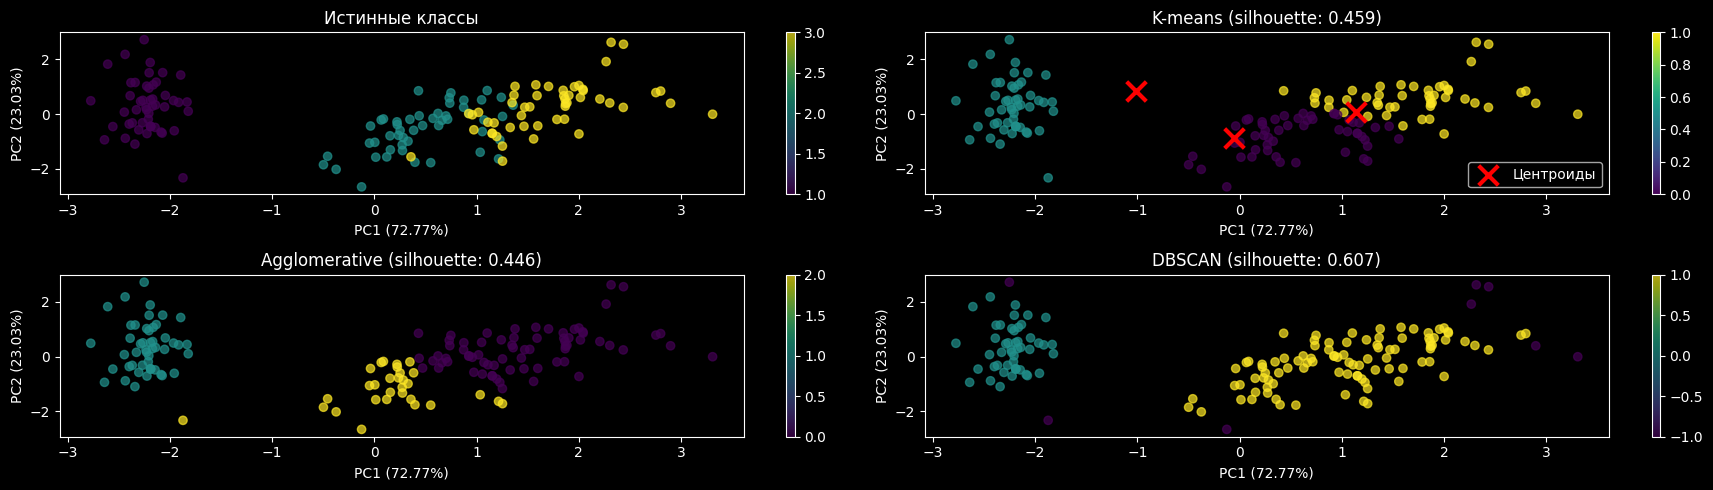

In [207]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

plt.figure(figsize=(18, 5))

plt.subplot(2, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('Истинные классы')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar()

plt.subplot(2, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
               marker='x', s=200, linewidths=3, color='red', label='Центроиды')
plt.title(f'K-means (silhouette: {kmeans_score:.3f})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.colorbar()

plt.subplot(2, 2, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', alpha=0.7)
plt.title(f'Agglomerative (silhouette: {agg_score:.3f})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar()

plt.subplot(2, 2, 4)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.7)
plt.title(f'DBSCAN (silhouette: {dbscan_score:.3f})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar()

plt.tight_layout()
plt.show()

# Сравнение с реальными метками

In [208]:
kmeans_labels += 1

for idx in range(kmeans_labels.shape[0]): 
    if kmeans_labels[idx] == 2:
        kmeans_labels[idx] = 1
    elif kmeans_labels[idx] == 1:
        kmeans_labels[idx] = 2

kmeans_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3,
       2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3,
       3, 3, 3, 2, 2, 3, 3, 3, 3, 2, 3, 2, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3,
       3, 2, 2, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 2], dtype=int32)

In [209]:
for idx in range(agg_labels.shape[0]): 
    if agg_labels[idx] == 0:
        agg_labels[idx] = 3

agg_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 2, 3, 2, 3, 2, 3, 2, 2, 3, 2, 3, 2, 3,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 2, 3, 3, 2,
       2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [210]:
y.values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [211]:
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
import seaborn as sns

def plot_and_save_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.plot()

kmeans:
    accuracy = 0.8333333333333334
    precision = 0.8339355011374281

agglomerative clustering:
    accuracy = 0.8266666666666667
    precision = 0.8586854460093897



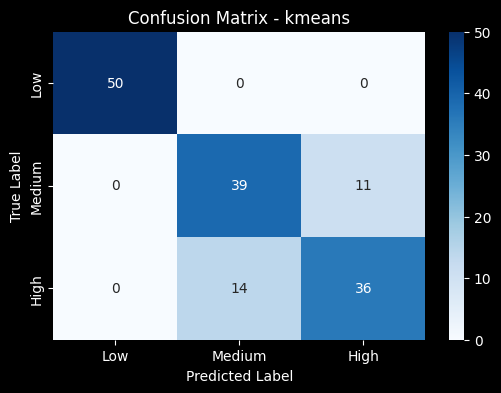

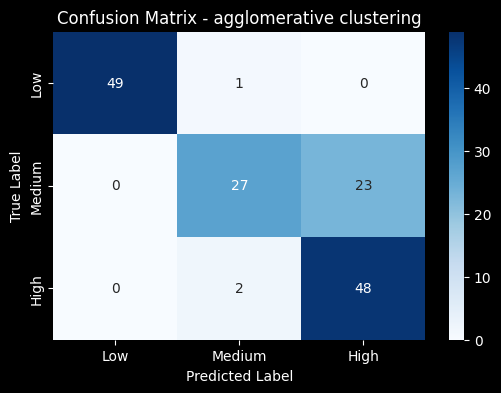

In [212]:
for labels, name in [
    (kmeans_labels, 'kmeans'), 
    (agg_labels, 'agglomerative clustering')
]: 
    print(f'{name}:')
    print(f'    accuracy = {accuracy_score(y.values, labels)}')
    print(f'    precision = {precision_score(y.values, labels, average="weighted")}')
    print()

    plot_and_save_confusion_matrix(y.values, labels, name)